# 🎓 Smart Career Path Recommendation — New Model Training Notebook

**Project:** Smart Career Path Recommendation System for Nigerian Secondary School Students  
**Classes:** SSS 1, SSS 2, and SS3
**Data source:** Synthetic dataset grounded in Nigerian NERDC curriculum & WAEC grading bands  
**Models:** Random Forest (baseline) + XGBoost (primary)  
**Target:** 10 Nigerian career path labels

---

## Folder structure expected
```
ml/
├── train_model.ipynb          ← This notebook
├── data/
│   └── nigerian_career_dataset.csv
└── ml/
    └── models/                ← Trained .pkl files saved here
```

# Libraries and Data Check

In [252]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import joblib

In [253]:
data = pd.read_excel(r'C:\Users\USER\Documents\projects\surplus-project\ml\data\Nigerian_Career_Survey_Derived_Dataset_200_filled.xlsx')
df = pd.DataFrame(data)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# Data Cleaning

In [254]:
df = df.fillna(0)
df = df.drop(columns=['French', 'History', 'Age_Group'])
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_', regex=False)

# create Age column
df['age'] = np.random.randint(17, 25, size=len(df))


df['school_type'] = df['school_type'].replace({
    "Federal Government College": "Government School",
    "Public": "Government School",
    "Mission": "Mission / Faith School",
    "Private": "Private School",
    "igbo hausa": "igbo / hausa"
})

df = df.rename(columns={"current_career_path": "career_path"})
df = df.rename(columns={"current_career_path": "career_path"})


print(f"Shape of dataset: rows={df.shape[0]}, columns={df.shape[1]}")
print("\nDistribution of Labels (target variables):")
print(df['career_path'].value_counts())
print("\nDistribution of Class Departments:")
print(df['department'].value_counts())
print("\nDistribution of school type:")
print(df['school_type'].value_counts())
print("\nMissing Values:")
print(df.isnull().sum())

Shape of dataset: rows=200, columns=40

Distribution of Labels (target variables):
career_path
Law & Social Sciences                   32
Business & Finance                      27
Mass Communication & Media              26
Agriculture & Environmental Sciences    24
Entrepreneurship & Management           19
Engineering & Technology                17
Medicine & Health Sciences              16
Creative Arts & Design                  15
Education & Humanities                  14
Computer Science & IT                   10
Name: count, dtype: int64

Distribution of Class Departments:
department
Science       67
Arts          67
Commercial    66
Name: count, dtype: int64

Distribution of school type:
school_type
Government School         95
Private School            59
Mission / Faith School    46
Name: count, dtype: int64

Missing Values:
respondent_id                                  0
gender                                         0
school_type                                    0
waec_y

In [255]:
# Ensuring that only the relevant subjects for each career path are considered, we will set the scores of other subjects to None for each career path.
agric_science_subj = ["english", "mathematics", "agricultural_science", "physics", "chemistry", "biology", "civic_education", "geography"]
law_subj = ["english", "literature_in_english", "government", "christian_religious_studies/islamic_studies", "civic_education", "yoruba", "economics", "mathematics"]
mass_com_subj = ["english", "literature_in_english", "government", "christian_religious_studies/islamic_studies", "civic_education", "marketing", "igbo_hausa", "mathematics"]
business_finance_subj = ["english", "mathematics", "civic_education", "igbo_hausa", "economics", "commerce", "government", "data_processing"]
education_humanities_subj = ["english", "mathematics", "civic_education", "christian_religious_studies/islamic_studies", "economics", "literature_in_english", "government", "data_processing", "yoruba"]
ent_management_subj = ["english", "mathematics", "civic_education", "data_processing", "economics", "financial_accounting", "commerce", "government"]
medicine_subj = ["english", "mathematics", "civic_education", "data_processing", "biology", "chemistry", "physics", "agricultural_science"]
comp_sci_subj = ["english", "mathematics", "civic_education", "computer_studies", "physics", "chemistry", "further_mathematics", "biology", "economics"]
eng_subj = ["english", "mathematics", "civic_education", "data_processing", "physics", "chemistry", "further_mathematics", "geography", "technical_drawing"]
creative_arts_subj = ["english", "mathematics", "civic_education", "marketing", "literature_in_english", "creative_arts", "yoruba", "government", "christian_religious_studies/islamic_studies"]

career_subject_map = {
    'Agriculture & Environmental Sciences': agric_science_subj,
    'Law & Social Sciences': law_subj,
    'Mass Communication & Media': mass_com_subj,
    'Business & Finance': business_finance_subj,
    'Education & Humanities': education_humanities_subj,
    'Entrepreneurship & Management': ent_management_subj,
    'Medicine & Health Sciences': medicine_subj,
    'Computer Science & IT': comp_sci_subj,
    'Engineering & Technology': eng_subj,
    'Creative Arts & Design': creative_arts_subj,
}

all_subject_cols = sorted({
    *agric_science_subj,
    *law_subj,
    *mass_com_subj,
    *business_finance_subj,
    *education_humanities_subj,
    *ent_management_subj,
    *medicine_subj,
    *comp_sci_subj,
    *eng_subj,
    *creative_arts_subj,
})

for career_path, allowed_subjects in career_subject_map.items():
    mask = df['career_path'] == career_path
    if mask.any():
        other_subjects = [subj for subj in all_subject_cols if subj not in allowed_subjects]
        df.loc[mask, other_subjects] = None

print("\nThe Dataset after cleaning:")
display(df.head(10))

# print("Saved the cleaned dataset to 'cleaned_dataset.xlsx'")
# df.to_excel("cleaned_dataset.xlsx", index=False)


The Dataset after cleaning:


,respondent_id,gender,school_type,waec_year,department,mathematics,english,civic_education,physics,chemistry,biology,further_mathematics,agricultural_science,geography,technical_drawing,computer_studies,yoruba,igbo_hausa,data_processing,literature_in_english,christian_religious_studies/islamic_studies,creative_arts,economics,financial_accounting,commerce,government,marketing,academic_strength,waec_credits,best_subject_category,cgpa,course_alignment,aptitude_score_10,cognitive_score_10,psychometric_avg_5,sentiment_avg_5,career_path,confidence_level,career_influence,age
0,R001,Male,Mission / Faith School,2023,Science,C,B,D,E,A,A,NaN,B,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,5,Science,2.70,4,10,9,4.3,3.8,Agriculture & Environmental Sciences,Not very confident,Personal passion,20
1,R002,Male,Private School,2020,Commercial,C,B,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D,NaN,NaN,A,D,NaN,A,NaN,NaN,C,NaN,High,7,Commercial,4.25,2,6,4,2.9,2.5,Law & Social Sciences,Very confident,WAEC performance,21
2,R003,Male,Private School,2022,Arts,D,B,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,A,B,NaN,NaN,NaN,NaN,A,D,High,7,Arts,4.85,5,10,6,2.6,4.9,Mass Communication & Media,Somewhat confident,Financial considerations,21
3,R004,Male,Government School,2021,Commercial,C,C,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,D,NaN,NaN,NaN,C,NaN,B,E,NaN,Low,5,Commercial,2.81,2,8,7,4.6,2.6,Business & Finance,Not very confident,Parents,24
4,R005,Male,Government School,2020,Arts,D,B,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D,NaN,D,C,C,NaN,F,NaN,NaN,C,NaN,Average,6,Arts,3.19,5,10,9,3.3,3.6,Education & Humanities,Very confident,WAEC performance,17
5,R006,Female,Mission / Faith School,2023,Arts,A,A,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D,NaN,NaN,B,C,NaN,A,NaN,NaN,A,NaN,High,9,Arts,4.14,3,7,5,3.6,2.9,Law & Social Sciences,Not very confident,Teacher advice,21
6,R007,Male,Private School,2021,Science,B,B,A,B,C,A,NaN,A,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,9,Science,3.95,5,8,10,3.2,3.1,Agriculture & Environmental Sciences,Not very confident,WAEC performance,24
7,R008,Male,Mission / Faith School,2023,Science,D,D,D,D,D,B,NaN,D,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,1,Science,2.63,4,5,7,3.6,4.4,Agriculture & Environmental Sciences,Not very confident,WAEC performance,18
8,R009,Male,Mission / Faith School,2020,Science,B,C,C,B,A,A,NaN,B,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,7,Science,4.32,2,4,8,4.0,2.1,Agriculture & Environmental Sciences,Somewhat confident,Personal passion,17
9,R010,Male,Government School,2025,Science,D,D,D,D,D,A,NaN,E,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,1,Science,1.93,3,10,5,4.0,2.5,Agriculture & Environmental Sciences,Very confident,Teacher advice,22


# Exploratory Data Analysis

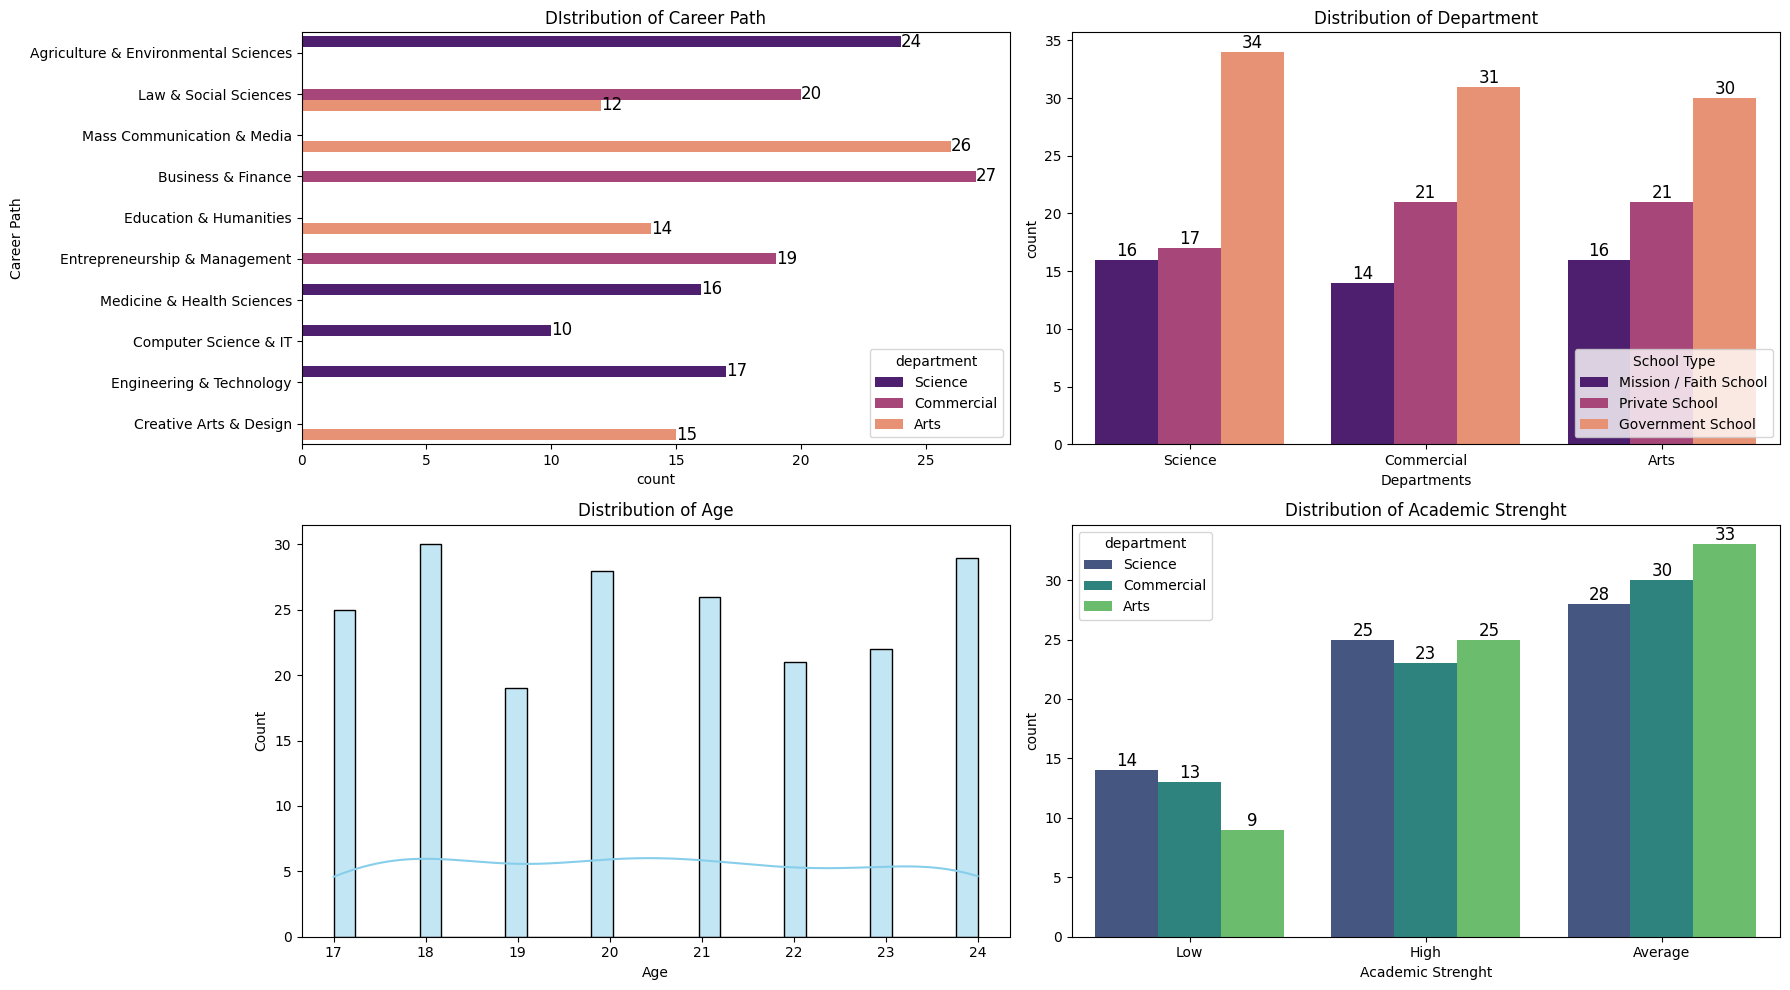

In [256]:
plt.figure(figsize=(18, 10))
plt.subplot(2, 2, 1)

# Distribution of Career path
sns.countplot(y="career_path", data=df, hue="department", palette="magma")
for container in plt.gca().containers:
    plt.bar_label(container, fontsize=12)
plt.title("DIstribution of Career Path")
plt.ylabel("Career Path")

# Distribution of departments
plt.subplot(2, 2, 2)
sns.countplot(x="department", data=df, hue="school_type", palette="magma")
plt.title("Distribution of Department")
for container in plt.gca().containers:
    plt.bar_label(container, fontsize=12)
plt.xlabel("Departments")
plt.legend(title="School Type", loc="lower right")

# Distribution of Age
plt.subplot(2, 2, 3)
sns.histplot(x="age", data=df, bins=30, kde=True, color='skyblue', edgecolor='black')
plt.title("Distribution of Age")
plt.xlabel("Age")

# Distribution of Acadmic Strenght
plt.subplot(2, 2, 4)
sns.countplot(x="academic_strength", data=df, hue="department", palette="viridis")
plt.title("Distribution of Academic Strenght")
for container in plt.gca().containers:
    plt.bar_label(container, fontsize=12)
plt.xlabel("Academic Strenght")

plt.tight_layout()
plt.show()


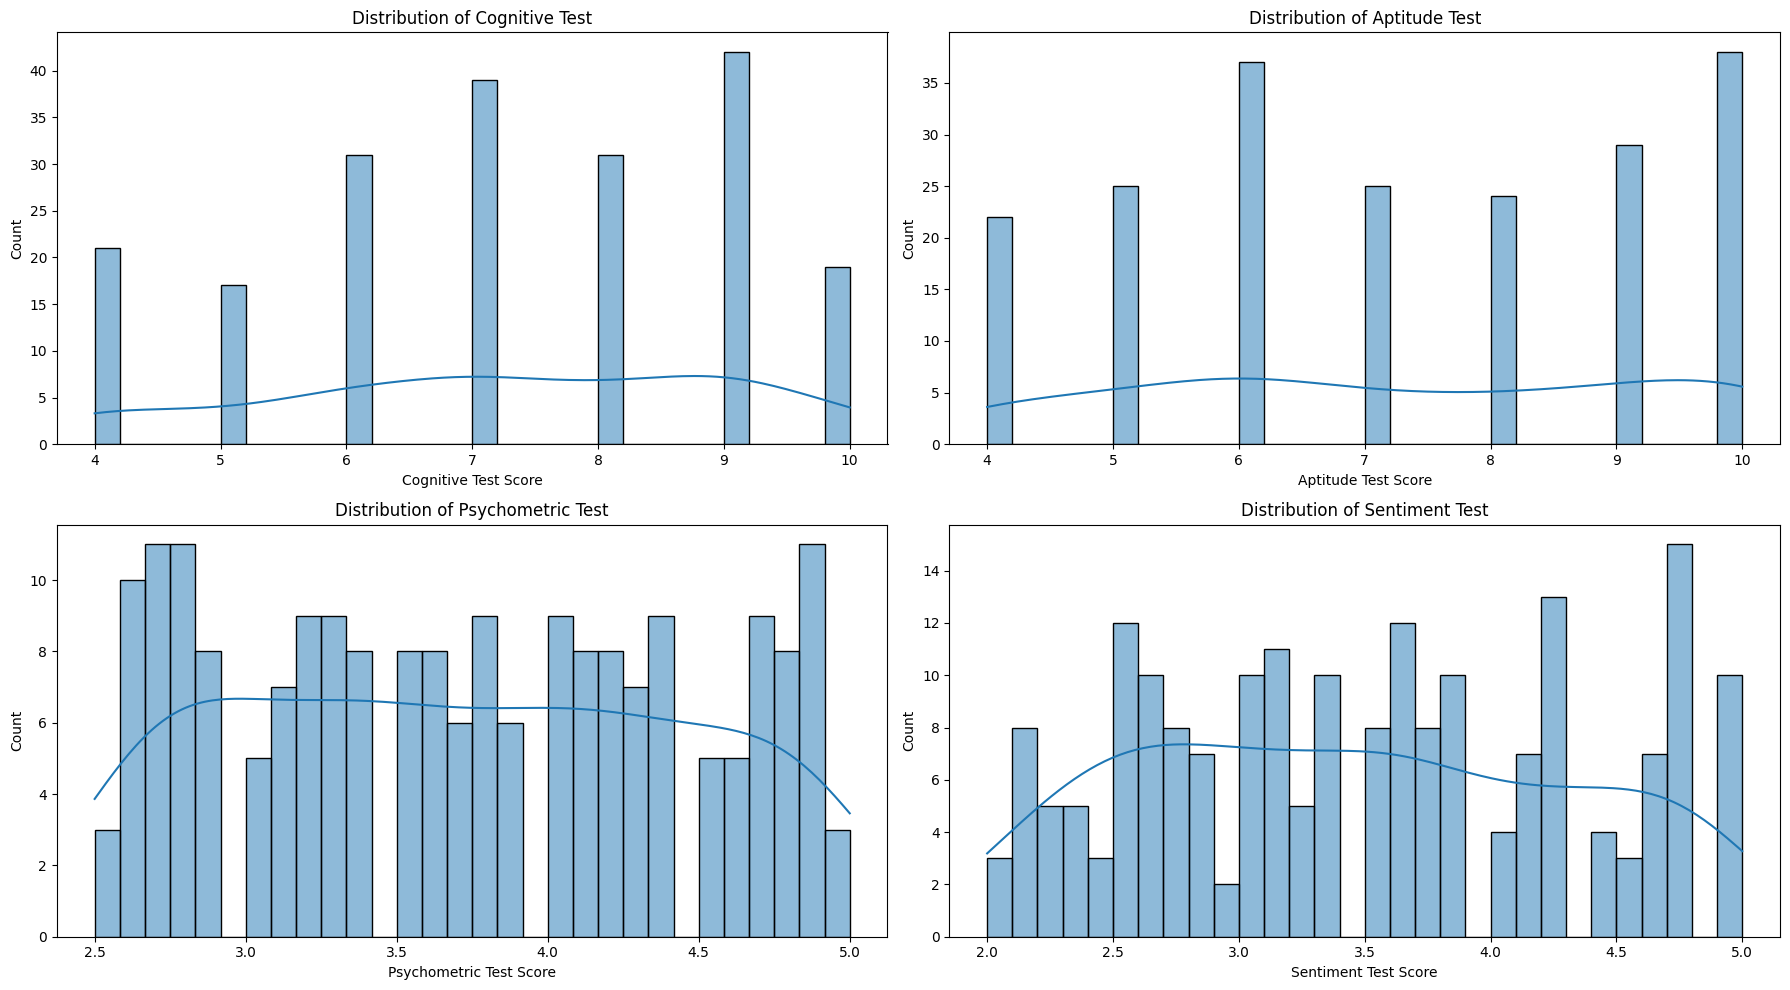

In [257]:
# Distribution of all Tests
plt.figure(figsize=(18, 10))

# Cognitive Test
plt.subplot(2, 2, 1)
sns.histplot(df['cognitive_score_10'].dropna(), bins=30, kde=True)
plt.title("Distribution of Cognitive Test")
plt.xlabel("Cognitive Test Score")

# Aptitude Test
plt.subplot(2, 2, 2)
sns.histplot(df['aptitude_score_10'].dropna(), bins=30, kde=True)
plt.title("Distribution of Aptitude Test")
plt.xlabel("Aptitude Test Score")

# Psychometric Test
plt.subplot(2, 2, 3)
sns.histplot(df['psychometric_avg_5'].dropna(), bins=30, kde=True)
plt.title("Distribution of Psychometric Test")
plt.xlabel("Psychometric Test Score")

# Sentiment Test
plt.subplot(2, 2, 4)
sns.histplot(df['sentiment_avg_5'].dropna(), bins=30, kde=True)
plt.title("Distribution of Sentiment Test")
plt.xlabel("Sentiment Test Score")

plt.tight_layout()
plt.show()

# Preprocessing Pipeline for Feature Engineering, Scaling and Encoding

In [258]:
subjects_cols = ["mathematics", "english", "civic_education", "physics", "chemistry", "biology", "further_mathematics", "agricultural_science", "geography", "technical_drawing", "computer_studies", "yoruba", "igbo_hausa", "data_processing",
                 "literature_in_english", "christian_religious_studies/islamic_studies", "creative_arts", "economics", "financial_accounting", "commerce", "government", "marketing"]
categorical_columns = ["gender", "school_type", "department", "academic_strength", "best_subject_category", "confidence_level", "career_influence"] + subjects_cols
numerical_columns = ["age", "waec_year", "waec_credits", "cgpa", "course_alignment", "aptitude_score_10", "cognitive_score_10", "psychometric_avg_5", "sentiment_avg_5"]


preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_columns),
    ('cat', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_columns)
])

display(preprocessor)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

# Build Feature Matrix

In [259]:
features = categorical_columns + numerical_columns
label_encoder = LabelEncoder()

# add any missing columns with sensible defaults to avoid KeyError
missing = [c for c in features if c not in df.columns]
for c in missing:
    df[c] = 0.0 if c in numerical_columns else "Unknown"

X = df[features].copy()
y = df["career_path"]
y_encoded = label_encoder.fit_transform(df['career_path'])

print("First 5 rows of X (Features):")
display(X.head())
print("\nDistribution of y (target):")
print(y.value_counts())
print("\nUnique classes in target variable:", label_encoder.classes_)

First 5 rows of X (Features):


,gender,school_type,department,academic_strength,best_subject_category,confidence_level,career_influence,mathematics,english,civic_education,physics,chemistry,biology,further_mathematics,agricultural_science,geography,technical_drawing,computer_studies,yoruba,igbo_hausa,data_processing,literature_in_english,christian_religious_studies/islamic_studies,creative_arts,economics,financial_accounting,commerce,government,marketing,age,waec_year,waec_credits,cgpa,course_alignment,aptitude_score_10,cognitive_score_10,psychometric_avg_5,sentiment_avg_5
0,Male,Mission / Faith School,Science,Low,Science,Not very confident,Personal passion,C,B,D,E,A,A,NaN,B,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20,2023,5,2.70,4,10,9,4.3,3.8
1,Male,Private School,Commercial,High,Commercial,Very confident,WAEC performance,C,B,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D,NaN,NaN,A,D,NaN,A,NaN,NaN,C,NaN,21,2020,7,4.25,2,6,4,2.9,2.5
2,Male,Private School,Arts,High,Arts,Somewhat confident,Financial considerations,D,B,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,A,B,NaN,NaN,NaN,NaN,A,D,21,2022,7,4.85,5,10,6,2.6,4.9
3,Male,Government School,Commercial,Low,Commercial,Not very confident,Parents,C,C,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,D,NaN,NaN,NaN,C,NaN,B,E,NaN,24,2021,5,2.81,2,8,7,4.6,2.6
4,Male,Government School,Arts,Average,Arts,Very confident,WAEC performance,D,B,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D,NaN,D,C,C,NaN,F,NaN,NaN,C,NaN,17,2020,6,3.19,5,10,9,3.3,3.6



Distribution of y (target):
career_path
Law & Social Sciences                   32
Business & Finance                      27
Mass Communication & Media              26
Agriculture & Environmental Sciences    24
Entrepreneurship & Management           19
Engineering & Technology                17
Medicine & Health Sciences              16
Creative Arts & Design                  15
Education & Humanities                  14
Computer Science & IT                   10
Name: count, dtype: int64

Unique classes in target variable: ['Agriculture & Environmental Sciences' 'Business & Finance'
 'Computer Science & IT' 'Creative Arts & Design' 'Education & Humanities'
 'Engineering & Technology' 'Entrepreneurship & Management'
 'Law & Social Sciences' 'Mass Communication & Media'
 'Medicine & Health Sciences']


# Train Test Split (80/20)

In [260]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, shuffle=True, stratify=y_encoded)

print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Class balance in train:")
unique, counts = np.unique(y_train, return_counts=True)
for i, c in zip(unique, counts):
    print(f"  {label_encoder.inverse_transform([i])[0]}: {c}")


Train size: 160 | Test size: 40
Class balance in train:
  Agriculture & Environmental Sciences: 19
  Business & Finance: 21
  Computer Science & IT: 8
  Creative Arts & Design: 12
  Education & Humanities: 11
  Engineering & Technology: 14
  Entrepreneurship & Management: 15
  Law & Social Sciences: 26
  Mass Communication & Media: 21
  Medicine & Health Sciences: 13


# Baseline Model - Random Forest

In [261]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=300,
    max_depth=18,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1))
])

# Ensure preprocessor uses the normalized column names (underscores) to match X_train
cat_cols_norm = [c.lower().strip().replace(' ', '_').replace('__', '_') for c in categorical_columns]
num_cols_norm = [c.lower().strip().replace(' ', '_').replace('__', '_') for c in numerical_columns]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_norm),
    ('cat', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols_norm)
])

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=18,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

# Evaluation
rf_accuracy = accuracy_score(y_test, rf_model.predict(X_test))
print(f"Random Forest Test Accuracy: {rf_accuracy*100:.2f}%")
print(f"Random Forest Train Accuracy: {accuracy_score(y_train, rf_model.predict(X_train))*100:.2f}%")

# Classification Report
rf_classification_report = classification_report(y_test, rf_model.predict(X_test))
print("\nClassification Report for Random Forest Model:")
print(rf_classification_report)

Random Forest Test Accuracy: 100.00%
Random Forest Train Accuracy: 100.00%

Classification Report for Random Forest Model:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00         6
           8       1.00      1.00      1.00         5
           9       1.00      1.00      1.00         3

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



## Visualize Random Forest Classification Report 

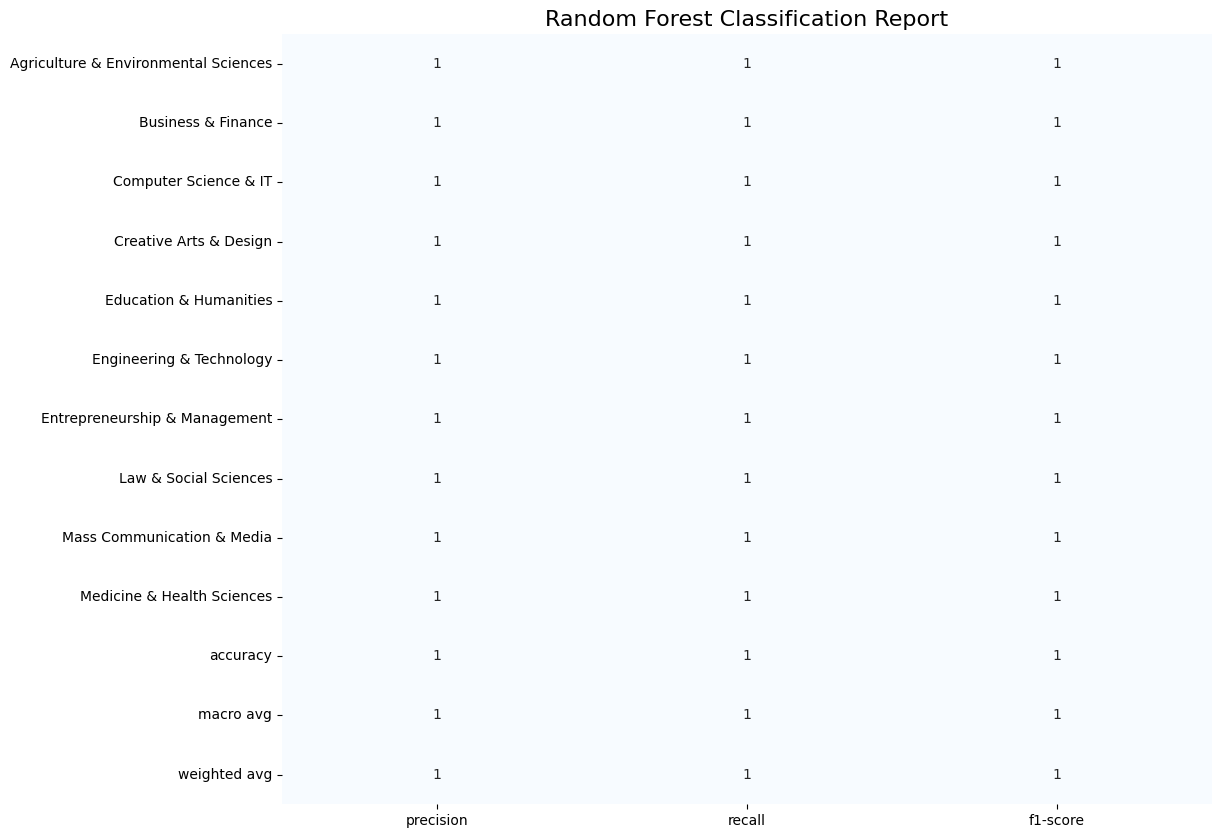

In [262]:
rf_classification_report_dict = classification_report(y_test, rf_model.predict(X_test), target_names=label_encoder.classes_, output_dict=True)

# Plot Random Forest Classification Report
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pd.DataFrame(rf_classification_report_dict).iloc[:-1, :].T, annot=True, cmap="Blues", cbar=False, ax=ax)
ax.set_title("Random Forest Classification Report", fontsize=16)
#plt.savefig("ml/models/classification_report.png", dpi=120, bbox_inches="tight")
plt.show()

# Primary Model 1 - XGBoost 

In [263]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=400,
    max_depth=8,
    learning_rate=0.01,
    subsample=0.85,
    colsample_bytree=0.80,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0))
])

xgb_model.fit(X_train, y_train)

# Evaluation
xgb_accuracy = accuracy_score(y_test, xgb_model.predict(X_test))
print(f"XGBoost Classifier Test Accuracy: {xgb_accuracy*100:.2f}%")
print(f"XGBoost Classifier Train Accuracy: {accuracy_score(y_train, xgb_model.predict(X_train)) * 100:.2f}%")

# Classification Report
xgb_classification_report = classification_report(y_test, xgb_model.predict(X_test))
print("\nXGBoost Classification Report:")
print(xgb_classification_report)

XGBoost Classifier Test Accuracy: 100.00%
XGBoost Classifier Train Accuracy: 100.00%

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00         6
           8       1.00      1.00      1.00         5
           9       1.00      1.00      1.00         3

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



## Visualize XGBoost Classification Report

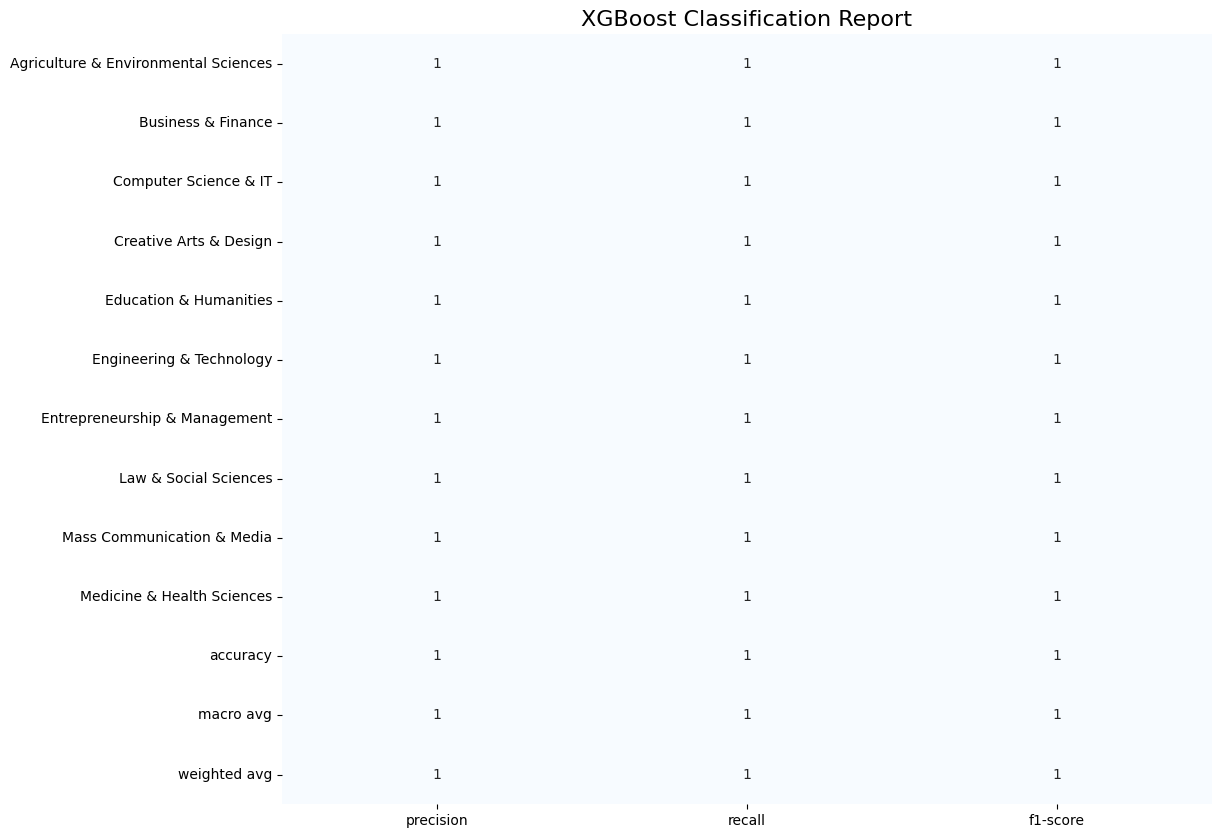

In [264]:
xgb_classification_report_dict = classification_report(y_test, xgb_model.predict(X_test), target_names=label_encoder.classes_, output_dict=True)
# Plot Random Forest Classification Report
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pd.DataFrame(xgb_classification_report_dict).iloc[:-1, :].T, annot=True, cmap="Blues", cbar=False, ax=ax)
ax.set_title("XGBoost Classification Report", fontsize=16)
#plt.savefig("ml/models/classification_report.png", dpi=120, bbox_inches="tight")
plt.show()

# Hyperparameter Tuning - XGBoost

In [265]:
param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__learning_rate': [0.01, 0.1, 0.2, 0.3],
    'classifier__max_depth': [3, 5, 7, 9],
    'classifier__min_child_weight': [1, 3, 5, 7],
    'classifier__gamma': [0, 0.1, 0.2, 0.3],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_model,                
    param_distributions=param_distributions,  
    n_iter=20,                          
    cv=5,                              
    scoring='accuracy',
    random_state=42,
    n_jobs=-1                           
)   

# Fit to data
xgb_random_search.fit(X_train, y_train)

# Access results
print(f"Best Parameters: {xgb_random_search.best_params_}")
print(f"Best CV Score: {xgb_random_search.best_score_:.4f}")
print(f"Best Estimator: {xgb_random_search.best_estimator_}")

# Fit best model
xgb_best_model = xgb_random_search.best_estimator_

# Predict on test set
xgb_best_model_pred = xgb_best_model.predict(X_test)
test_accuracy = (xgb_best_model_pred == y_test).mean()
print(f"Test accuracy of tuned XGBoost: {test_accuracy*100:.2f}%")
print(f"Train Accuracy of Tuned XGBoost: {accuracy_score(y_train, xgb_best_model.predict(X_train))*100:.2f}%")
print(f"Accuracy Score for Xgboost before tuning: {xgb_accuracy}")
print(f"Model Improvement: {(accuracy_score(y_test, xgb_best_model.predict(X_test)) - xgb_accuracy)*100:.2f}%")

Best Parameters: {'classifier__subsample': 1.0, 'classifier__n_estimators': 500, 'classifier__min_child_weight': 1, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.2, 'classifier__gamma': 0.2, 'classifier__colsample_bytree': 0.8}
Best CV Score: 0.9938
Best Estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'waec_year',
                                                   'waec_credits', 'cgpa',
                                                   'course_alignment',
                                                   'aptitude_score_10',
                                                   'cognitive_score_10',
                                                   'psychometric_avg_5',
                                                   'sentiment_avg_5']),
                                                 ('cat',
                                                 

# Cross Validation and Model Comparison

In [266]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv  = cross_val_score(rf_model,  X, y, cv=cv, scoring="accuracy", n_jobs=-1)
xgb_cv = cross_val_score(xgb_best_model, X, y_encoded, cv=cv, scoring="accuracy", n_jobs=-1)

print(f"Random Forest  CV: {rf_cv.mean()*100:.2f}% ± {rf_cv.std()*100:.2f}%")
print(f"XGBoost Tuned  CV: {xgb_cv.mean()*100:.2f}% ± {xgb_cv.std()*100:.2f}%")

Random Forest  CV: 100.00% ± 0.00%
XGBoost Tuned  CV: 99.50% ± 1.00%


# Confusion Matrix and Classification Report (XGBoost Tuned Model)

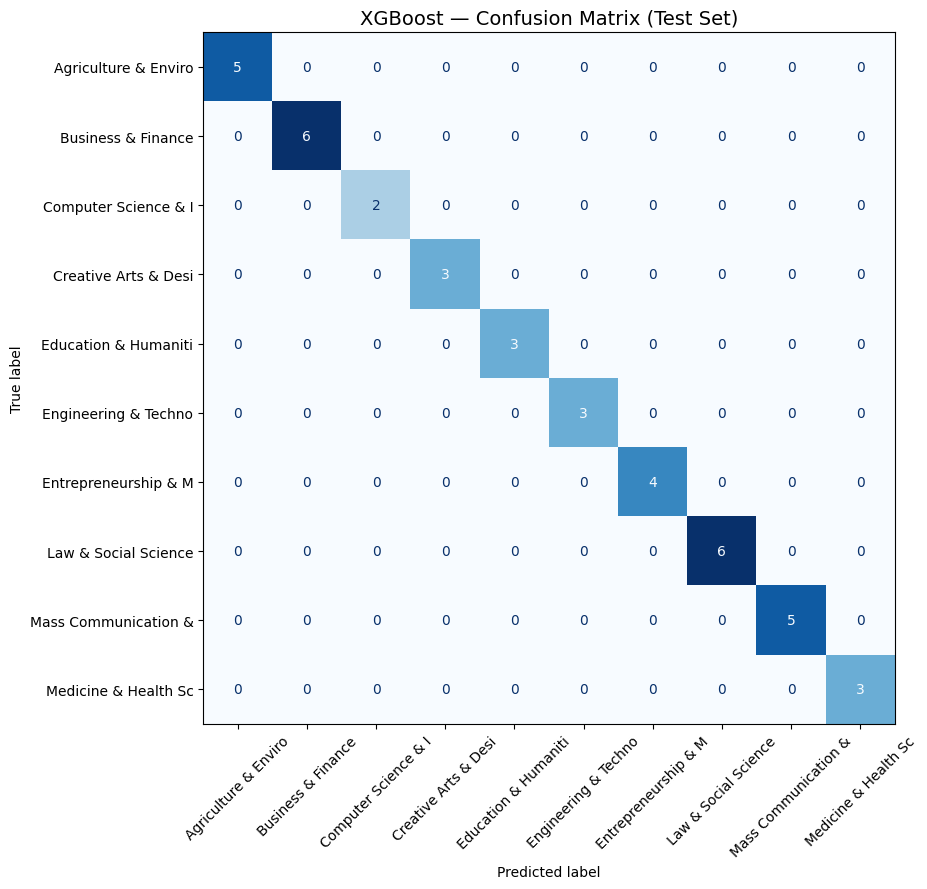

In [267]:
fig, ax = plt.subplots(figsize=(12, 9))
cm = confusion_matrix(y_test, xgb_best_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[c[:20] for c in label_encoder.classes_])
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues")
ax.set_title("XGBoost — Confusion Matrix (Test Set)", fontsize=14)
plt.tight_layout()
# plt.savefig("ml/models/confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


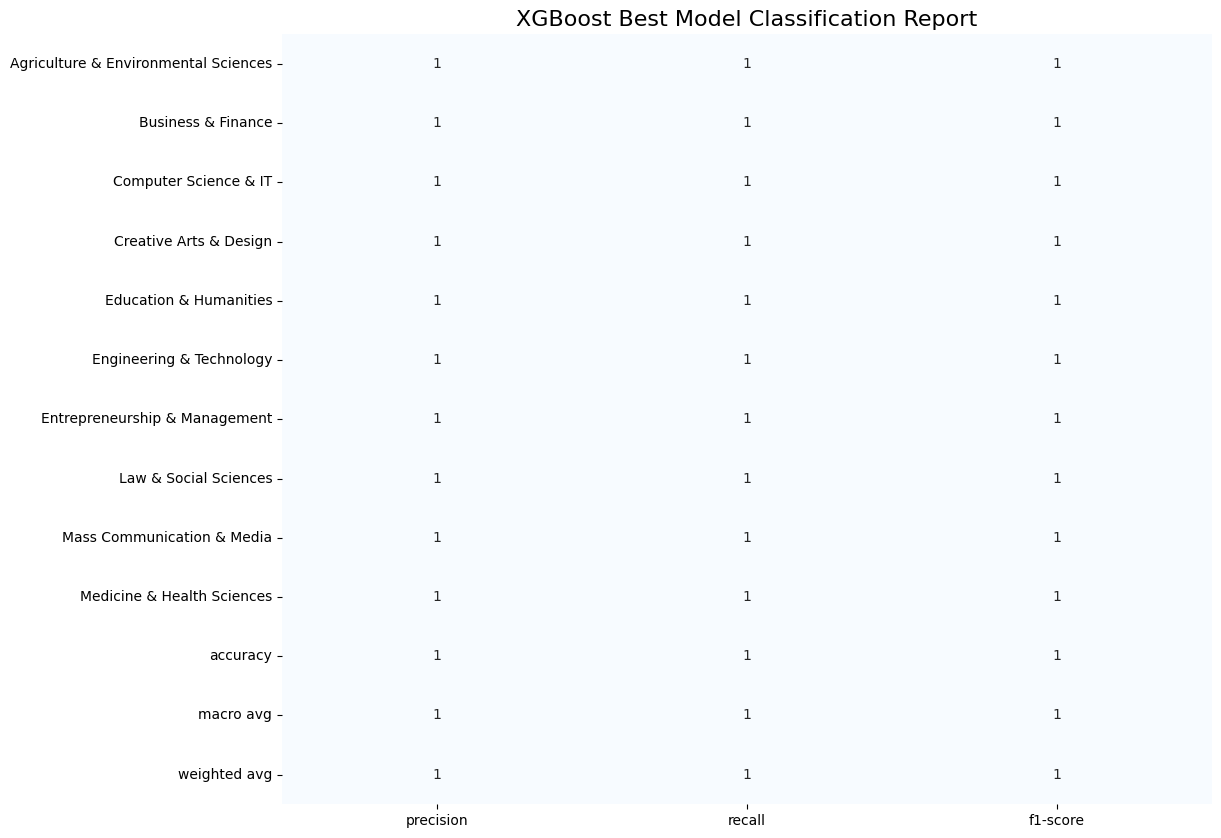

In [268]:
xgb_best_classification_report_dict = classification_report(y_test, xgb_best_model.predict(X_test), target_names=label_encoder.classes_, output_dict=True)
# Plot Random Forest Classification Report
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pd.DataFrame(xgb_best_classification_report_dict).iloc[:-1, :].T, annot=True, cmap="Blues", cbar=False, ax=ax)
ax.set_title("XGBoost Best Model Classification Report", fontsize=16)
#plt.savefig("ml/models/classification_report.png", dpi=120, bbox_inches="tight")
plt.show()

# Feature importance - XGBoost Tuned Model

Top 20 Feature Importances from XGBOost Tuned Model:


,Features,Importances
0,aptitude_score_10,0.086464
1,economics,0.076203
2,financial_accounting,0.072861
3,cgpa,0.070902
4,chemistry,0.067569
5,creative_arts,0.060827
6,cognitive_score_10,0.056641
7,marketing,0.054123
8,government,0.052906
9,christian_religious_studies/islamic_studies,0.052002


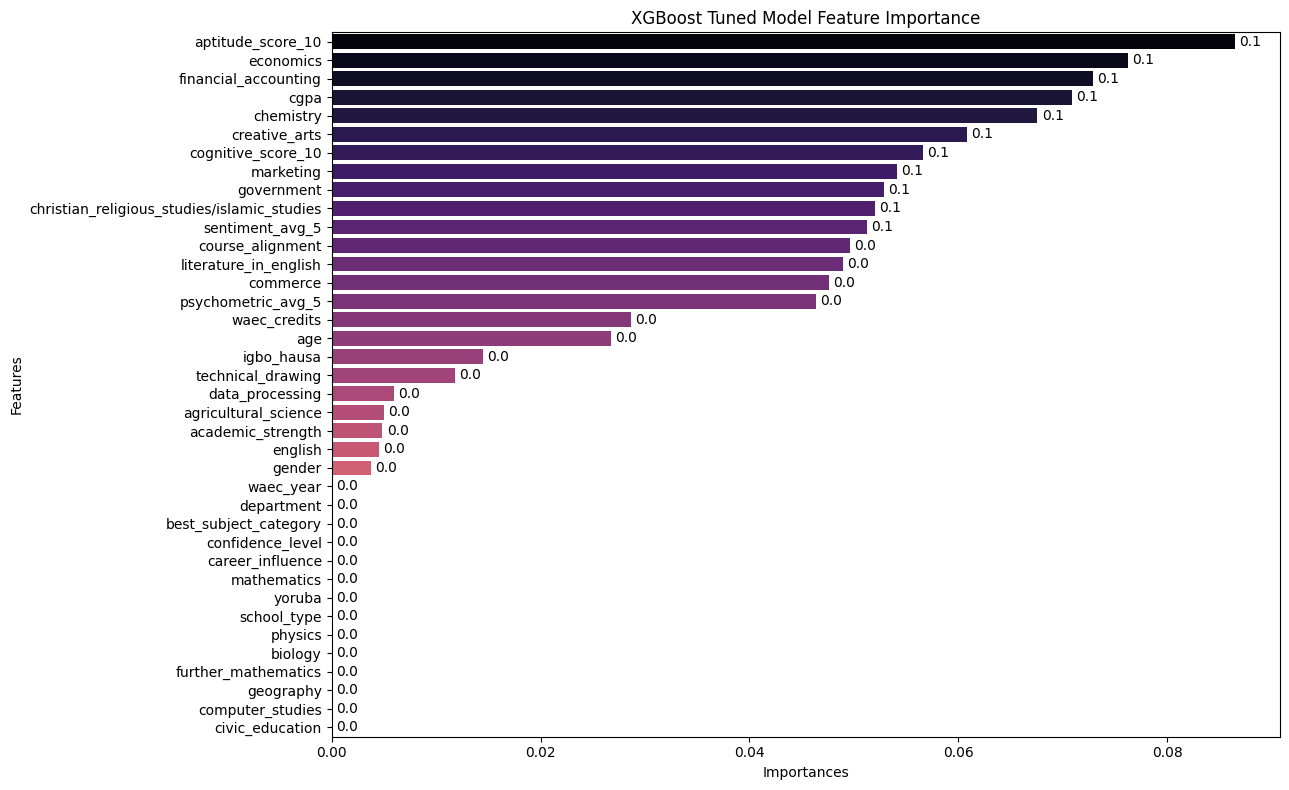

In [269]:
feature_importance = pd.DataFrame({
    'Features': features,
    'Importances': xgb_best_model.named_steps['classifier'].feature_importances_
}).sort_values(by='Importances', ascending=False).reset_index(drop=True)
print('Top 20 Feature Importances from XGBOost Tuned Model:')
display(feature_importance.head(20))

#Plotting XGBoost Tuned Model Feature Importance
plt.figure(figsize=(13, 8))
sns.barplot(x='Importances', y='Features', data=feature_importance, hue='Features', palette='magma', errorbar=None, legend=False)
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f', label_type='edge', padding=3)
plt.title('XGBoost Tuned Model Feature Importance')
plt.xlabel('Importances')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Save Files

In [270]:
import joblib
from pathlib import Path

# Resolve the correct models directory regardless of the notebook working directory
cwd = Path.cwd()
if (cwd / "new_model.ipynb").exists():
    model_dir = cwd / "models"
else:
    model_dir = cwd / "ml" / "models"

model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "xgb_best_model.pkl"
encoder_path = model_dir / "label_encoder.pkl"

joblib.dump(xgb_best_model, model_path)
joblib.dump(label_encoder, encoder_path)

print("Saved model artifacts to:")
print(f"  - {model_path}")
print(f"  - {encoder_path}")

expected = [model_path, encoder_path]
print("Model file checklist:")
for f in expected:
    size = f.stat().st_size if f.exists() else 0
    status = f"✅  {size/1024:.1f} KB" if f.exists() else "❌  MISSING"
    print(f"  {status}  {f}")

Saved model artifacts to:
  - c:\Users\USER\Documents\projects\mobile career app\ml\models\xgb_best_model.pkl
  - c:\Users\USER\Documents\projects\mobile career app\ml\models\label_encoder.pkl
Model file checklist:
  ✅  3411.3 KB  c:\Users\USER\Documents\projects\mobile career app\ml\models\xgb_best_model.pkl
  ✅  0.7 KB  c:\Users\USER\Documents\projects\mobile career app\ml\models\label_encoder.pkl


# Inference Test - Sample Student Prediction

In [271]:
# Sample SS Student (Pre-WAEC)
sample = {
    'Gender': 'Male',
    'Age': 23,
    'School_Type': 'Mission / Faith School',
    'Department': 'Science',
    'Mathematics': 'A',
    'English': 'A',
    'Civic Education': 'D',
    'Physics': 'E',
    'Chemistry': 'A',
    'Biology': 'A',
    'Agricultural Science': 'B',
    'Geography': 'D',
    'Academic_Strength': 'Low',
    'Best_Subject_Category': 'Science',
    'Confidence_Level': 'Not very confident',
    'Career_Influence': 'Personal passion',
    'WAEC_Credits': 5,
    'CGPA': 2.7,
    'Aptitude_Score_10': 10,
    'Cognitive_Score_10': 9,
    'Psychometric_Avg_5': 4.3,
    'Sentiment_Avg_5': 4.0
}

df_sample = pd.DataFrame([sample])

# Add missing columns with sensible defaults
all_expected_cols = [
    'Gender', 'School_Type', 'Department', 'Academic_Strength', 'Best_Subject_Category',
    'Mathematics', 'English', 'Civic Education', 'Physics', 'Chemistry', 'Biology',
    'Further Mathematics', 'Agricultural Science', 'Geography', 'Technical Drawing',
    'Computer Studies', 'Yoruba', 'Igbo Hausa', 'Data Processing', 'Literature In English',
    'History', 'Christian Religious Studies/Islamic Studies', 'French', 'Creative Arts',
    'Economics', 'Financial Accounting', 'Commerce', 'Government', 'Marketing',
    'WAEC_Credits', 'CGPA', 'Course_Alignment', 'Aptitude_Score_10', 'Cognitive_Score_10',
    'Psychometric_Avg_5', 'Sentiment_Avg_5', 'Confidence_Level', 'Career_Influence'
]

for col in all_expected_cols:
    if col not in df_sample.columns:
        if col in ['WAEC_Credits', 'CGPA', 'Course_Alignment', 'Aptitude_Score_10',
                   'Cognitive_Score_10', 'Psychometric_Avg_5', 'Sentiment_Avg_5']:
            df_sample[col] = 0.0 if col != 'WAEC_Credits' else 5.0
        else:
            df_sample[col] = 'Unknown'   # or a common default like 'C'

# Grade mapping for all grade columns
grade_map = {'A':8, 'B':6, 'C':5, 'D':3, 'E':2, 'F':1, 'Unknown':5}
grade_cols = [col for col in all_expected_cols if col not in ['Gender','School_Type','Department',
              'Academic_Strength','Best_Subject_Category','Confidence_Level','Career_Influence',
              'WAEC_Credits','CGPA','Course_Alignment','Aptitude_Score_10','Cognitive_Score_10',
              'Psychometric_Avg_5','Sentiment_Avg_5']]

for col in grade_cols:
    if col in df_sample.columns:
        df_sample[col] = df_sample[col].astype(str).str.upper().map(grade_map).fillna(5)
        # Align the sample dataframe with the exact feature names used by the trained model
        df_sample = df_sample.rename(columns=lambda c: str(c).lower())

        for col in features:
            if col not in df_sample.columns:
                df_sample[col] = 0.0 if col in numerical_columns else "Unknown"

        for col in numerical_columns:
            if col in df_sample.columns:
                df_sample[col] = pd.to_numeric(df_sample[col], errors="coerce").fillna(0.0)

        df_sample = df_sample[features]
        df_sample = df_sample.astype({col: 'float64' if col in numerical_columns else 'object' for col in features})

if sample["Mathematics"] == "F" or sample["English"] == "F":
    print("\nWarning: The student has failed in Mathematics or English. Career recommendations may not be accurate.")
    predicted_career = "None, please improve your grades in Mathematics and English to get career recommendations."
    proba = [0] * len(label_encoder.classes_)
else:
    pred_encoded = xgb_best_model.predict(df_sample)[0]
    proba = xgb_best_model.predict_proba(df_sample)[0]
    predicted_career = label_encoder.inverse_transform([pred_encoded])[0]

print("\n=== SS Student Career Prediction ===")
print(f"**Predicted Career:** {predicted_career}")
print(f"Confidence: {max(proba)*100:.1f}%")

print("\nTop 3:")
for c, p in sorted(zip(label_encoder.classes_, proba), key=lambda x: x[1], reverse=True)[:3]:
    print(f"  • {c} ({p*100:.1f}%)")


=== SS Student Career Prediction ===
**Predicted Career:** Business & Finance
Confidence: 19.5%

Top 3:
  • Business & Finance (19.5%)
  • Creative Arts & Design (18.7%)
  • Agriculture & Environmental Sciences (17.7%)
